# Group the Actinobacteria genomes by order

Joins the NCBI order of each genome (`01_get_taxonomy.py`) with the HMM search results of the two pathways
(`hmm_search/results/raw/Actinobacteria/*.tblout`), as the input for the order-level heatmap.

- **vnz/Ara pathway:** lacI-AraR, AraB, AraA, AraD
- **SCO pathway:** SCO2401, SCO2402, SCO2403, SCO2407, SCO2439, SCO2440

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_DIR = Path("/vol/local/calarass/Projects/ara_comp_genomics")
TAXONOMY_DIR = PROJECT_DIR / "taxonomy_heatmap" / "results" / "taxonomy"
HMM_RAW_DIR = PROJECT_DIR / "hmm_search" / "results" / "raw" / "Actinobacteria"
GENOMES_DIR = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/genomes")

# reuse the .tblout parser of the hmm_search pipeline
sys.path.insert(0, str(PROJECT_DIR / "hmm_search" / "scripts"))
presence_absence = importlib.import_module("08_presence_absence")

PATHWAYS = {
    "vnz/Ara": ["lacI-AraR", "AraB", "AraA", "AraD"],
    "SCO": ["SCO2401", "SCO2402", "SCO2403", "SCO2407", "SCO2439", "SCO2440"],
}
GENE_TO_PATHWAY = {gene: pathway for pathway, genes in PATHWAYS.items() for gene in genes}

## Orders

In [2]:
order_counts = pd.read_csv(TAXONOMY_DIR / "order_counts.tsv", sep="\t")
print(f"{order_counts.genomes.sum()} genomes in {len(order_counts)} orders")
order_counts

253 genomes in 32 orders


,class,order,genomes
0,Acidimicrobiia,Acidimicrobiales,6
1,Actinomycetes,Micrococcales,93
2,Actinomycetes,Mycobacteriales,22
3,Actinomycetes,Propionibacteriales,19
4,Actinomycetes,Pseudonocardiales,15
5,Actinomycetes,Actinomycetales,14
6,Actinomycetes,Micromonosporales,11
7,Actinomycetes,Streptosporangiales,9
8,Actinomycetes,Kitasatosporales,8
9,Actinomycetes,Bifidobacteriales,4


In [3]:
taxonomy = pd.read_csv(TAXONOMY_DIR / "taxonomy_orders.tsv", sep="\t")
taxonomy.head()

,genome,assembly,taxid,class,order,family,genus
0,Acidimicrobium_ferrooxidans_DSM_10331,GCF_000023265.1,525909,Acidimicrobiia,Acidimicrobiales,Acidimicrobiaceae,Acidimicrobium
1,Acidipropionibacterium_acidipropionici_ATCC_4875,GCF_000310065.1,1171373,Actinomycetes,Propionibacteriales,Propionibacteriaceae,Acidipropionibacterium
2,Acidothermaceae_bacterium_B102,GCA_033097465.1,3061014,Actinomycetes,Acidothermales,Acidothermaceae,NaN
3,Acidothermus_cellulolyticus_11B_ATCC_43068,GCF_000015025.1,351607,Actinomycetes,Acidothermales,Acidothermaceae,Acidothermus
4,Actinacidiphila_bryophytorum_DS3,GCF_024927965.1,1436133,Actinomycetes,Kitasatosporales,Streptomycetaceae,Actinacidiphila


## Name lookup: taxonomy genome -> HMM genome

The taxonomy table uses the genome names of the COG table (= the folder names in `lipid_genomics/actinos/genomes/`),
while the `.faa` and `.tblout` files are named after the organism in each genome's GenBank file
(`lipid_genomics/scripts/gbk_to_faa.py`), e.g. `Acidothermus_cellulolyticus_11B_ATCC_43068` vs
`Acidothermus_cellulolyticus_11B`. The organism name is read from the `ORGANISM` line of the `.gbff`
(joining continuation lines, as Biopython does), with the square brackets NCBI puts around doubtful genera
removed, since the files were renamed without them (e.g. `[Actinomadura]_parvosata...`).

In [4]:
def organism_name(genome_dir):
    """Organism name of a genome folder as used for its .faa/.tblout file, or None."""
    gbff = next(genome_dir.glob("ncbi_dataset/data/*/genomic.gbff"), None)
    if gbff is None:
        return None
    with open(gbff) as fh:
        for line in fh:
            if line.startswith("  ORGANISM"):
                parts = [line[12:].strip()]
                # long names wrap onto the next line; the lineage lines that
                # follow contain ';'
                for line in fh:
                    if ";" in line or not line.startswith(" " * 12):
                        break
                    parts.append(line.strip())
                name = " ".join(parts).replace(" ", "_")
                return name.replace("[", "").replace("]", "")
    return None


taxonomy["hmm_name"] = [organism_name(GENOMES_DIR / genome) for genome in taxonomy.genome]

tblout_names = {path.stem for path in HMM_RAW_DIR.glob("*.tblout")}
matched = taxonomy.hmm_name.isin(tblout_names)
print(f"{matched.sum()} of {len(taxonomy)} genomes matched to a .tblout file")
print("not matched:")
print(taxonomy.loc[~matched, ["genome", "hmm_name", "order"]].to_string(index=False))
print("tblout files without a genome:", sorted(tblout_names - set(taxonomy.hmm_name)))

252 of 253 genomes matched to a .tblout file
not matched:
                   genome hmm_name         order
Allobranchiibius_GilTou73     None Micrococcales
tblout files without a genome: []


## HMM hits

In [5]:
PATH_TO_HMM_DIR = PROJECT_DIR / "hmm_search" / "results"
actino_hmm_results = pd.read_csv(PATH_TO_HMM_DIR / "actino_top_hits_after_synteny.tsv", sep="\t")
print(f"{len(actino_hmm_results)} best hits from {actino_hmm_results.tblout.nunique()} genomes")
actino_hmm_results.status.value_counts()

1919 best hits from 252 genomes


status
fail         1539
pass          327
Soft_pass      53
Name: count, dtype: int64

In [6]:
actino_passes = actino_hmm_results[actino_hmm_results.status == "pass"]


In [7]:
MIN_GENOMES = 9
ALWAYS_KEEP = ["Kitasatosporales"]  # Streptomyces and relatives: the reference order of the study

large_orders = order_counts[(order_counts.genomes >= MIN_GENOMES) | order_counts.order.isin(ALWAYS_KEEP)]
print(f"{len(large_orders)} orders with >= {MIN_GENOMES} genomes, "
      f"{large_orders.genomes.sum()} of {order_counts.genomes.sum()} genomes")
large_orders

10 orders with >= 9 genomes, 210 of 253 genomes


,class,order,genomes
1,Actinomycetes,Micrococcales,93
2,Actinomycetes,Mycobacteriales,22
3,Actinomycetes,Propionibacteriales,19
4,Actinomycetes,Pseudonocardiales,15
5,Actinomycetes,Actinomycetales,14
6,Actinomycetes,Micromonosporales,11
7,Actinomycetes,Streptosporangiales,9
8,Actinomycetes,Kitasatosporales,8
23,Coriobacteriia,Eggerthellales,10
24,Coriobacteriia,Coriobacteriales,9


In [8]:
# add the taxonomy of each genome to its HMM hits (tblout = .faa/.tblout name = taxonomy.hmm_name)
actino_hmm_taxonomy = actino_hmm_results.merge(
    taxonomy[["genome", "hmm_name", "assembly", "class", "order", "family", "genus"]]
        .rename(columns={"genome": "taxonomy_genome"}),
    left_on="tblout", right_on="hmm_name", how="left",
)

# genomes without a taxonomy match would have no order: should print none
print("hits without taxonomy:", actino_hmm_taxonomy.loc[actino_hmm_taxonomy.order.isna(), "tblout"].unique())

# keep only the genomes in the large orders
actino_hmm_taxonomy = actino_hmm_taxonomy[actino_hmm_taxonomy.order.isin(large_orders.order)]
print(f"{len(actino_hmm_taxonomy)} hits from {actino_hmm_taxonomy.tblout.nunique()} genomes "
      f"in {actino_hmm_taxonomy.order.nunique()} orders")
actino_hmm_taxonomy.groupby("order").tblout.nunique().rename("genomes with HMM results")

hits without taxonomy: []
1589 hits from 209 genomes in 10 orders


order
Actinomycetales        14
Coriobacteriales        9
Eggerthellales         10
Kitasatosporales        8
Micrococcales          92
Micromonosporales      11
Mycobacteriales        22
Propionibacteriales    19
Pseudonocardiales      15
Streptosporangiales     9
Name: genomes with HMM results, dtype: int64

In [9]:
actino_hmm_taxonomy

,target,target_acc,model,model_acc,evalue,bitscore,bias,best_dom_evalue,best_dom_bitscore,best_dom_bias,...,passes,status,near_passing,taxonomy_genome,hmm_name,assembly,class,order,family,genus
3,Actinokineospora_sp._UTMC_2448|Actkin_RS14370|...,-,AraB,-,0.0000,1033.8,9.5,0.0000,1033.6,9.5,...,True,pass,NaN,Actinokineospora_UTMC_2448,Actinokineospora_sp._UTMC_2448,GCF_024760565.1,Actinomycetes,Pseudonocardiales,Pseudonocardiaceae,Actinokineospora
4,Crossiella_sp._CA-258035|N8J89_RS16055|ribulok...,-,AraB,-,0.0000,1025.2,7.7,0.0000,1025.1,7.7,...,True,pass,NaN,Crossiella_CA-258035,Crossiella_sp._CA-258035,GCF_030064675.1,Actinomycetes,Pseudonocardiales,Pseudonocardiaceae,Crossiella
5,Lentzea_guizhouensis|BBK82_RS39535|ribulokinas...,-,AraB,-,0.0000,1025.0,10.2,0.0000,1024.9,10.2,...,True,pass,NaN,Lentzea_guizhouensis_DHS_C013,Lentzea_guizhouensis,GCF_001701025.1,Actinomycetes,Pseudonocardiales,Pseudonocardiaceae,Lentzea
6,Actinosynnema_mirum_DSM_43827|AMIR_RS09340|rib...,-,AraB,-,0.0000,1017.4,9.7,0.0000,1017.2,9.7,...,True,pass,NaN,Actinosynnema_mirum_DSM_43827,Actinosynnema_mirum_DSM_43827,GCF_000023245.1,Actinomycetes,Pseudonocardiales,Pseudonocardiaceae,Actinosynnema
7,Paenarthrobacter_aurescens_TC1|AAUR_RS18505|ri...,-,AraB,-,0.0000,1014.8,5.2,0.0000,1014.7,5.2,...,True,pass,NaN,Paenarthrobacter_aurescens_TC1_ATCC_BAA-1386,Paenarthrobacter_aurescens_TC1,GCF_000014925.1,Actinomycetes,Micrococcales,Micrococcaceae,Paenarthrobacter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,Renibacterium_salmoninarum_ATCC_33209|RSAL3320...,-,SCO2407,-,0.0250,11.0,0.0,0.0290,10.8,0.0,...,False,fail,NaN,Renibacterium_salmoninarum_ATCC_33209,Renibacterium_salmoninarum_ATCC_33209,GCF_000018885.1,Actinomycetes,Micrococcales,Micrococcaceae,Renibacterium
1914,Tropheryma_whipplei_str._Twist|TWT_RS05030|hyp...,-,AraA,-,0.0058,11.0,0.1,0.0064,10.8,0.1,...,False,fail,NaN,Tropheryma_whipplei_Twist,Tropheryma_whipplei_str._Twist,GCF_000007485.1,Actinomycetes,Micrococcales,Tropherymataceae,Tropheryma
1916,Allosaccharopolyspora_coralli|GIY23_RS20560|GNAT,-,AraA,-,0.0320,10.9,0.1,0.0390,10.6,0.1,...,False,fail,NaN,Allosaccharopolyspora_coralli_E2A,Allosaccharopolyspora_coralli,GCF_009664835.1,Actinomycetes,Pseudonocardiales,Pseudonocardiaceae,Allosaccharopolyspora
1917,Salinispora_tropica_CNB-440|STROP_RS07820|pyri...,-,AraA,-,0.0370,10.7,0.1,0.0470,10.4,0.1,...,False,fail,NaN,Salinispora_tropica_CNB-440,Salinispora_tropica_CNB-440,GCF_000016425.1,Actinomycetes,Micromonosporales,Micromonosporaceae,Salinispora


In [10]:
# genomes per order with a passing hit for each gene (one best hit per genome and gene, so rows = genomes)
present = actino_hmm_taxonomy[actino_hmm_taxonomy.status == "pass"]

gene_columns = [gene for genes in PATHWAYS.values() for gene in genes]
contingency = (
    pd.crosstab(present.order, present.gene)
    .reindex(index=large_orders.order, columns=gene_columns, fill_value=0)
)
# genomes with HMM results per order, for fractions later
contingency.insert(0, "n_genomes", actino_hmm_taxonomy.groupby("order").tblout.nunique())
contingency

gene,n_genomes,lacI-AraR,AraB,AraA,AraD,SCO2401,SCO2402,SCO2403,SCO2407,SCO2439,SCO2440
order,,,,,,,,,,,
Micrococcales,92,1,21,45,51,0,0,0,0,0,0
Mycobacteriales,22,0,2,2,2,0,0,0,0,0,0
Propionibacteriales,19,0,7,10,13,0,0,0,0,0,1
Pseudonocardiales,15,1,5,5,5,2,2,1,0,3,2
Actinomycetales,14,0,5,5,8,0,0,0,0,0,0
Micromonosporales,11,0,6,8,8,2,1,1,1,0,4
Streptosporangiales,9,3,4,2,4,0,0,0,0,0,1
Kitasatosporales,8,5,4,4,4,2,2,2,1,2,2
Eggerthellales,10,0,0,0,0,0,0,0,0,0,0


## Streptomycetaceae: combined with the Streptomycetae genome set

The Actinobacteria set has only 8 Kitasatosporales genomes (2 *Streptomyces*). The Streptomycetae set (207 genomes)
was searched with the same HMM profiles and called against the same thresholds (`selection_criteria.ipynb`,
`strep_top_hits.tsv`; pass/fail only, no synteny soft passes). Kitasatosporales is replaced by two rows:
*Streptomyces* and the other Streptomycetaceae genera. Genomes in both sets are counted once (from the
Streptomycetae set). *[Kitasatospora] papulosa* counts as *Streptomyces*: it sits inside *Streptomyces* in the
Streptomycetae tree (see `history_readme.md`).

In [11]:
import re

STREP_ROWS = ["Streptomyces", "other Streptomycetaceae"]
COUNT_AS_STREPTOMYCES = {"Kitasatospora_papulosa"}


def name_key(name):
    """Compare genome names of the two sets on letters and digits only."""
    return re.sub(r"[^a-z0-9]", "", name.lower())


strep_hmm_results = pd.read_csv(PATH_TO_HMM_DIR / "strep_top_hits.tsv", sep="\t")
strep_hmm_results["name"] = strep_hmm_results.tblout.str.replace(r"_protein$", "", regex=True)

# Kitasatosporales genomes of the Actinobacteria set that are not in the Streptomycetae set
kitasato = actino_hmm_taxonomy[actino_hmm_taxonomy.order == "Kitasatosporales"].assign(name=lambda df: df.tblout)
in_strep_set = kitasato.name.map(name_key).isin(set(strep_hmm_results.name.map(name_key)))
print("Kitasatosporales genomes in both sets (counted once):", sorted(kitasato.loc[in_strep_set, "name"].unique()))
print("added from the Actinobacteria set:", sorted(kitasato.loc[~in_strep_set, "name"].unique()))

streptomycetaceae = pd.concat([strep_hmm_results[["name", "gene", "status"]],
                               kitasato.loc[~in_strep_set, ["name", "gene", "status"]]], ignore_index=True)
is_streptomyces = (streptomycetaceae.name.str.split("_").str[0] == "Streptomyces") | \
    streptomycetaceae.name.isin(COUNT_AS_STREPTOMYCES)
streptomycetaceae["row"] = is_streptomyces.map({True: STREP_ROWS[0], False: STREP_ROWS[1]})

strep_present = streptomycetaceae[streptomycetaceae.status == "pass"]
strep_counts = (
    pd.crosstab(strep_present.row, strep_present.gene)
    .reindex(index=STREP_ROWS, columns=gene_columns, fill_value=0)
)
strep_counts.insert(0, "n_genomes", streptomycetaceae.groupby("row").name.nunique())

# replace the Kitasatosporales row by the two Streptomycetaceae rows
contingency = pd.concat([contingency.drop(index="Kitasatosporales"), strep_counts])
contingency

Kitasatosporales genomes in both sets (counted once): ['Kitasatospora_setae_KM-6054', 'Peterkaempfera_bronchialis', 'Streptantibioticus_cattleyicolor_NRRL_8057_=_DSM_46488', 'Streptomyces_coelicolor_A3(2)']
added from the Actinobacteria set: ['Actinacidiphila_bryophytorum', 'Streptacidiphilus_sp._P02-A3a', 'Streptomyces_griseus_subsp._griseus_NBRC_13350', 'Yinghuangia_sp._ASG_101']


gene,n_genomes,lacI-AraR,AraB,AraA,AraD,SCO2401,SCO2402,SCO2403,SCO2407,SCO2439,SCO2440
Micrococcales,92,1,21,45,51,0,0,0,0,0,0
Mycobacteriales,22,0,2,2,2,0,0,0,0,0,0
Propionibacteriales,19,0,7,10,13,0,0,0,0,0,1
Pseudonocardiales,15,1,5,5,5,2,2,1,0,3,2
Actinomycetales,14,0,5,5,8,0,0,0,0,0,0
Micromonosporales,11,0,6,8,8,2,1,1,1,0,4
Streptosporangiales,9,3,4,2,4,0,0,0,0,0,1
Eggerthellales,10,0,0,0,0,0,0,0,0,0,0
Coriobacteriales,9,0,0,2,4,0,0,0,0,0,0
Streptomyces,194,39,25,24,26,129,128,127,98,124,130


## Order tree + heatmap

Order-level tree from the old whole-genome tree (`lipid_genomics/actinos/output_WGS_tree_actinos`), midpoint-rooted until the tree with outgroups is ready; each order collapsed to one tip.

In [12]:
from collections import Counter

import re
from Bio import Phylo

# old whole-genome tree (PhyloPhlAn + IQ-TREE, 2026-03-20), no outgroup yet
OLD_TREE = Path("/vol/local/calarass/Projects/lipid_genomics/actinos/output_WGS_tree_actinos/faa.tre.treefile")


def tip_key(name):
    """Tree tips are the .faa names with IQ-TREE's replacements ('[', ']', '(', ')', '=' -> '_'),
    so tips and HMM names are compared on their letters and digits only."""
    return re.sub(r"[^a-z0-9]", "", name.lower())


named = taxonomy.dropna(subset=["hmm_name"])
key_to_order = dict(zip(named.hmm_name.map(tip_key), named.order))

tree = Phylo.read(OLD_TREE, "newick")
# temporary root until the tree with outgroups is ready: the midpoint root separates
# Coriobacteriia from all other classes
tree.root_at_midpoint()
tip_to_order = {tip.name: key_to_order.get(tip_key(tip.name)) for tip in tree.get_terminals()}
print("tips without an order:", [tip for tip, order in tip_to_order.items() if order is None])

# keep only the genomes of the large orders
for tip in tree.get_terminals():
    if tip_to_order[tip.name] not in set(large_orders.order):
        tree.prune(tip)

# does each order form one clade (among the large orders)? if not, which orders sit inside it
not_monophyletic = {}
for order in large_orders.order:
    order_tips = [tip for tip in tree.get_terminals() if tip_to_order[tip.name] == order]
    if not tree.is_monophyletic(order_tips):
        inside = Counter(tip_to_order[tip.name] for tip in tree.common_ancestor(order_tips).get_terminals())
        del inside[order]
        not_monophyletic[order] = dict(inside)
print("orders that are not one clade:", not_monophyletic)

# collapse each order to one tip: keep one genome per order and name the tip after the order
kept = set()
for tip in tree.get_terminals():
    order = tip_to_order[tip.name]
    if order in kept:
        tree.prune(tip)
    else:
        kept.add(order)
        tip.name = order
# Kitasatosporales is shown as two rows, Streptomyces and the other Streptomycetaceae genera; the other genera
# are not one clade (Kitasatospora branches outside Streptomyces, several others inside or next to it)
for tip in tree.get_terminals():
    if tip.name == "Kitasatosporales":
        tip.clades = [type(tip)(name=row) for row in STREP_ROWS]
        tip.name = None
not_monophyletic[STREP_ROWS[1]] = "genera around and inside Streptomyces"
tree.ladderize()

# rotate the branches (groupings unchanged) so that Streptomyces is the top row: at every node on the
# path from the root to it, the branch leading to Streptomyces is drawn first
TOP_ROW = "Streptomyces"
path = [tree.root] + tree.get_path(TOP_ROW)
for parent, child in zip(path, path[1:]):
    parent.clades.remove(child)
    parent.clades.insert(0, child)
order_rows = [tip.name for tip in tree.get_terminals()]
Phylo.draw_ascii(tree)

tips without an order: []
orders that are not one clade: {'Micrococcales': {'Actinomycetales': 14}}
                          , Streptomyces
                   _______|
                  |       | other Streptomycetaceae
                  |
                 ,| _________ Micromonosporales
                 |,|
                 |||  ________ Pseudonocardiales
                 |||_|
                 ||  |___________ Mycobacteriales
                 ||
  _______________|| _________ Propionibacteriales
 |               |||
 |               | | ____________ Micrococcales
 |               | ||
_|               |  |_____________ Actinomycetales
 |               |
 |               |__________ Streptosporangiales
 |
 |                  _________________________________ Coriobacteriales
 |_________________|
                   |________________ Eggerthellales



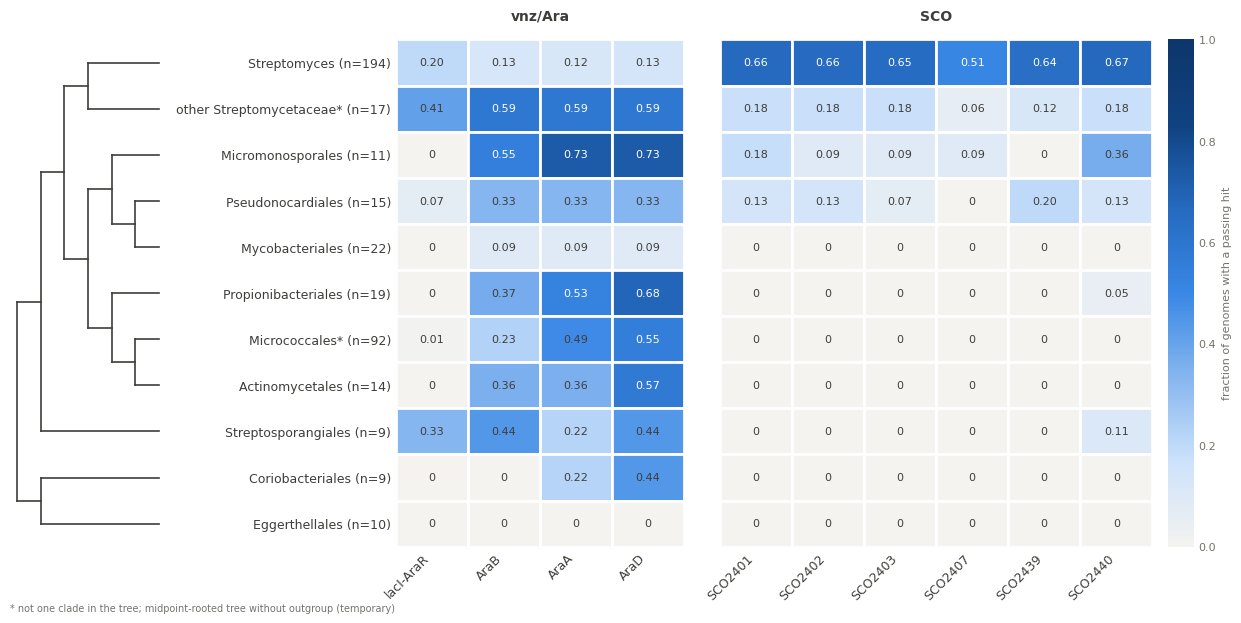

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

# rows follow the order tree; colour and cell text = fraction of the genomes in each order with a
# passing hit (the number of genomes per order is in the row label)
fractions = contingency.loc[order_rows, gene_columns].div(contingency.loc[order_rows, "n_genomes"], axis=0)

# one hue, light -> dark: 0 sits close to the background, 1 is the darkest blue
CMAP = LinearSegmentedColormap.from_list(
    "fraction", ["#f4f3f0", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"]
)
INK = "#3d3d3a"       # text on light cells
INK_MUTED = "#73726c"
PATHWAY_GAP = 0.5     # blank space between the vnz/Ara and the SCO columns

# x position of each gene column, with the gap after the last vnz/Ara gene
n_ara = len(PATHWAYS["vnz/Ara"])
x_pos = [i + (PATHWAY_GAP if i >= n_ara else 0) for i in range(len(gene_columns))]


def cladogram_coords(tree):
    """x = node depth (tips aligned on the right), y = row centre of each clade."""
    x, y = {}, {}

    def set_x(clade, depth):
        x[clade] = depth
        for child in clade.clades:
            set_x(child, depth + 1)

    set_x(tree.root, 0)
    max_depth = max(x.values())
    for row, tip in enumerate(tree.get_terminals()):
        x[tip] = max_depth
        y[tip] = row + 0.5

    def set_y(clade):
        if not clade.is_terminal():
            child_y = [set_y(child) for child in clade.clades]
            y[clade] = (min(child_y) + max(child_y)) / 2
        return y[clade]

    set_y(tree.root)
    return x, y


fig, (tree_ax, ax) = plt.subplots(
    1, 2, figsize=(0.7 * len(gene_columns) + 5.5, 0.42 * len(order_rows) + 1.6),
    gridspec_kw={"width_ratios": [1.3, 0.7 * len(gene_columns)]},
)

# order tree (topology only; branch lengths not drawn)
x, y = cladogram_coords(tree)
for clade in tree.find_clades(order="preorder"):
    if clade.is_terminal():
        continue
    child_y = [y[child] for child in clade.clades]
    tree_ax.plot([x[clade], x[clade]], [min(child_y), max(child_y)], color=INK, linewidth=1.2)
    for child in clade.clades:
        tree_ax.plot([x[clade], x[child]], [y[child], y[child]], color=INK, linewidth=1.2)
tree_ax.set_ylim(len(order_rows), 0)
tree_ax.set_xlim(-0.2, max(x.values()) + 0.1)
tree_ax.axis("off")

# heatmap
for row, order in enumerate(order_rows):
    for col, gene in enumerate(gene_columns):
        value = fractions.loc[order, gene]
        ax.add_patch(plt.Rectangle((x_pos[col], row), 1, 1, facecolor=CMAP(value),
                                   edgecolor="white", linewidth=2))
        ax.text(x_pos[col] + 0.5, row + 0.5, f"{value:.2f}" if value else "0", ha="center", va="center",
                fontsize=8, color="white" if value > 0.5 else INK)

ax.set_xlim(0, x_pos[-1] + 1)
ax.set_ylim(len(order_rows), 0)
ax.set_xticks([x_ + 0.5 for x_ in x_pos], gene_columns, rotation=45, ha="right", fontsize=9, color=INK)
# * = the order is not one clade in the tree
ax.set_yticks([r + 0.5 for r in range(len(order_rows))],
              [f"{order}{'*' if order in not_monophyletic else ''} (n={contingency.loc[order, 'n_genomes']})"
               for order in order_rows], fontsize=9, color=INK)
ax.tick_params(length=0)
for side in ax.spines.values():
    side.set_visible(False)

# pathway names above their column blocks
for pathway, start, end in [("vnz/Ara", 0, n_ara), ("SCO", n_ara, len(gene_columns))]:
    middle = (x_pos[start] + x_pos[end - 1] + 1) / 2
    ax.text(middle, -0.35, pathway, ha="center", va="bottom", fontsize=10, color=INK, fontweight="bold")

colorbar = fig.colorbar(ScalarMappable(cmap=CMAP), ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("fraction of genomes with a passing hit", fontsize=8, color=INK_MUTED)
colorbar.ax.tick_params(labelsize=8, colors=INK_MUTED, length=0)
colorbar.outline.set_visible(False)

if not_monophyletic:
    fig.text(0.01, 0.01, "* not one clade in the tree; midpoint-rooted tree without outgroup (temporary)",
             fontsize=7, color=INK_MUTED)

fig.tight_layout()
plt.show()